In [339]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco 
import seaborn as sns

In [340]:
daily_returns = pd.read_csv(
    "data/processed/daily_returns.csv",
    index_col=0,
    parse_dates=True
)

adj_close = pd.read_csv(
    "data/processed/adj_close.csv",
    index_col=0,
    parse_dates=True
)

cov_matrix = pd.read_csv(
    "data/processed/cov_matrix.csv",
    index_col=0
)

metrics_table = pd.read_csv(
    "data/processed/metrics_table.csv",
    index_col=0
)

daily_rfr = pd.read_csv(
    "data/processed/daily_risk_free_rate.csv",
    index_col = 0
)

In [341]:
from src.metrics import portfolio_return, portfolio_volatility, sharpe_ratio, negative_sharpe

In [342]:
long_returns = daily_returns.reset_index().melt(id_vars = 'Date', value_vars = daily_returns.columns)
long_returns.columns = ['Date', 'Asset','Return']
long_returns['Date'] = pd.to_datetime(long_returns['Date'])
long_returns = long_returns.sort_values(['Asset','Date'])
daily_rfr.index = pd.to_datetime(daily_rfr.index)
long_returns = long_returns.merge(
    daily_rfr,
    left_on='Date',
    right_index= True,
    how = 'left'
)
long_returns['excess_return'] = long_returns['Return'] - long_returns['daily_rfr']
long_returns.head(22)

,Date,Asset,Return,daily_rfr,excess_return
0,2021-07-07,AGG,0.001728,0.000002,0.001726
1,2021-07-08,AGG,0.001121,0.000002,0.001119
2,2021-07-09,AGG,-0.003274,0.000002,-0.003276
3,2021-07-12,AGG,-0.000605,0.000002,-0.000607
4,2021-07-13,AGG,-0.002162,0.000002,-0.002164
5,2021-07-14,AGG,0.003381,0.000002,0.003379
6,2021-07-15,AGG,0.002159,0.000002,0.002157
7,2021-07-16,AGG,-0.000862,0.000002,-0.000864
8,2021-07-19,AGG,0.005263,0.000002,0.005261
9,2021-07-20,AGG,-0.000944,0.000002,-0.000946


In [343]:
long_adj_close = adj_close.reset_index().melt(id_vars = 'Date', value_vars = adj_close.columns).set_index('Date')
long_adj_close.columns = ['Asset','Adj_close']
long_adj_close = long_adj_close.sort_values(['Asset','Date'])
long_adj_close['log_return'] = (
    long_adj_close.groupby('Asset')['Adj_close'].transform(
        lambda x: np.log(x).diff())
    )
long_adj_close = long_adj_close.dropna(subset = ['log_return'])
long_data = long_returns.merge(
    long_adj_close,
    on = ('Date', 'Asset'),
    how = 'inner'
)
long_data.head()

,Date,Asset,Return,daily_rfr,excess_return,Adj_close,log_return
0,2021-07-07,AGG,0.001728,0.000002,0.001726,99.205017,0.001726
1,2021-07-08,AGG,0.001121,0.000002,0.001119,99.316254,0.001121
2,2021-07-09,AGG,-0.003274,0.000002,-0.003276,98.991089,-0.003279
3,2021-07-12,AGG,-0.000605,0.000002,-0.000607,98.931190,-0.000605
4,2021-07-13,AGG,-0.002162,0.000002,-0.002164,98.717255,-0.002165


## Static Optimized Portfolio - Baseline

In [344]:
model_results = pd.read_csv("data/processed/model_results.csv")
model_results

,Unnamed: 0,Eq_weights,Min_Variance,Sharpe,Asset_Class_Constrained,Class_and_Asset_Constrained
0,AGG,0.071429,0.8854,0.0000,0.250000,0.150000
1,EEM,0.071429,0.0000,0.0000,0.000000,0.000000
2,EFA,0.071429,0.0000,0.0000,0.150000,0.150000
3,GLD,0.071429,0.0038,0.5271,0.150000,0.150000
4,IWM,0.071429,0.0000,0.0000,0.000000,0.000000
5,LQD,0.071429,0.0000,0.0000,0.000000,0.100000
6,MTUM,0.071429,0.0136,0.0000,0.000000,0.050000
7,QQQ,0.071429,0.0000,0.0333,0.245800,0.150000
8,QUAL,0.071429,0.0000,0.0000,0.000000,0.000000
9,SPY,0.071429,0.0000,0.0000,0.004200,0.100000


In [345]:
weight_list = (
    0.15, #AGG
    0.00, #EEM
    0.15, #EFA
    0.15, #GLD
    0.00, #IWM
    0.10, #LQD
    0.05, #MTUM
    0.15, #QQQ
    0.00, #QUAL
    0.10, #SPY
    0.00, #TLT
    0.00, #USMV
    0.15, #VLUE
    0.00  #VNQ
)
if sum(weight_list) != 1:
    print("Does Not Equal 1")
else:
    print('Weights Equal 1')


Weights Equal 1


In [346]:
weights = {}
for i in range(len(daily_returns.columns)):
    key = daily_returns.columns[i]
    weight = weight_list[i]
    weights[key] = weight
long_data['weights'] = long_data['Asset'].map(weights)

In [347]:
long_data['weighted_returns'] = long_data['weights'] * long_data['Return']
weighted_returns_df = pd.DataFrame(long_data.groupby('Date')['weighted_returns'].sum()).reset_index()
weighted_returns_df['rolling_return'] = weighted_returns_df['weighted_returns'].rolling(21).mean()
weighted_returns_df['rolling_vol'] =  weighted_returns_df['weighted_returns'].rolling(21).std() * np.sqrt(252)
weighted_returns_df['portfolio_value'] = (
    1 + weighted_returns_df['weighted_returns']
).cumprod()
weighted_returns_df['running_peak'] = weighted_returns_df['portfolio_value'].cummax()
weighted_returns_df['drawdown'] = (
    weighted_returns_df['portfolio_value'] / weighted_returns_df['running_peak'] - 1
)


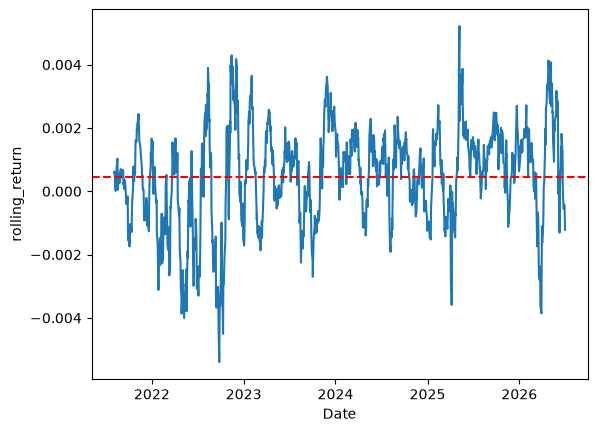

In [348]:
sns.lineplot(data = weighted_returns_df, x = 'Date', y = 'rolling_return')
plt.axhline(y=weighted_returns_df['weighted_returns'].mean(), color='red', linestyle='--')

## Time-Based Rebalancing Strategy

In [ ]:
tb_portfolio = long_data.copy()
tb_portfolio['quarter'] = pd.to_datetime(tb_portfolio['Date']).dt.quarter
tb_portfolio['Year'] = pd.to_datetime(tb_portfolio['Date']).dt.year

,Date,Asset,Return,daily_rfr,excess_return,Adj_close,log_return,weights,weighted_returns,quarter,Year
0,2021-07-07,AGG,0.001728,0.000002,0.001726,99.205017,0.001726,0.15,0.000259,3,2021
1,2021-07-08,AGG,0.001121,0.000002,0.001119,99.316254,0.001121,0.15,0.000168,3,2021
2,2021-07-09,AGG,-0.003274,0.000002,-0.003276,98.991089,-0.003279,0.15,-0.000491,3,2021
3,2021-07-12,AGG,-0.000605,0.000002,-0.000607,98.931190,-0.000605,0.15,-0.000091,3,2021
4,2021-07-13,AGG,-0.002162,0.000002,-0.002164,98.717255,-0.002165,0.15,-0.000324,3,2021


In [350]:
from src.config import portfolio_groups, asset_class_caps, asset_bounds
from src.optimization import build_constraints

tickers = daily_returns.columns

constraints = build_constraints(
    tickers,
    portfolio_groups,
    asset_class_caps
)

bounds = tuple(asset_bounds for _ in range(len(tickers)))

In [351]:
tb_portfolio_21q3 = tb_portfolio[(tb_portfolio['Year'] == 2021) & (tb_portfolio['quarter'] == 3)]
wr_21q3 = pd.DataFrame(tb_portfolio_21q3.groupby('Date')['weighted_returns'].sum()).reset_index()
wr_21q3['portfolio_value'] = (
    1 + wr_21q3['weighted_returns']
).cumprod()
wr_21q3['running_peak'] = wr_21q3['portfolio_value'].cummax()
wr_21q3['drawdown'] = (
    wr_21q3['portfolio_value'] / wr_21q3['running_peak'] - 1
)

In [ ]:
rebalanced_returns = wr_21q3.copy()


np.float64(-0.00020974544145397692)

In [361]:
initial = np.array([1 / len(daily_returns.columns)] * len(daily_returns.columns))
returns_21q3 = tb_portfolio_21q3.groupby('Asset')['Return'].sum()
rfr_21q3 = tb_portfolio_21q3['daily_rfr'].sum()

sco.minimize(
    negative_sharpe,
    initial, 
    args = (returns_21q3, cov_matrix, rfr_21q3),
    method = "SLSQP",
    bounds = bounds,
    constraints = constraints
)

     message: Positive directional derivative for linesearch
     success: False
      status: 8
         fun: 0.023731353381471986
           x: [ 1.500e-01  2.067e-10 ...  1.816e-15  1.500e-01]
         nit: 16
         jac: [ 3.216e-02  4.469e-01 ...  1.402e-01  2.190e-02]
        nfev: 205
        njev: 12
 multipliers: [ 2.000e+05  2.000e+05  2.000e+05  2.000e+05  2.000e+05
                2.000e+05]